# MIT-BIH Arrhythmia Database: Data Preprocessing and Segmentation

This notebook focuses on cleaning the raw ECG signals and segmenting the continuous waveform data into individual heartbeats. We will apply bandpass filtering, segment the signals around R-peaks, apply Z-score normalization, and export the preprocessed arrays for model training.

In [34]:
import datetime
import pathlib
import sys
import os
sys.path.append(str(pathlib.Path('.').resolve()))
# Helper to save figures in dated subfolders
def save_fig(fig, name, base_dir='assets'):
    date_str = datetime.date.today().isoformat()
    target_dir = pathlib.Path(base_dir) / date_str
    target_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'{name}_{timestamp}.png'
    path = target_dir / filename
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f'Figure saved to {path}')
    return str(path)
# Ensure base assets dir exists for compatibility
pathlib.Path('assets').mkdir(exist_ok=True)


## 1. Prerequisites and Setup

We import necessary modules, including the signal processing library `scipy.signal` to filter our ECG streams.

In [35]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.abspath("../../data/raw/mitdb")
OUTPUT_DIR = os.path.abspath("assets/data")

os.makedirs(OUTPUT_DIR, exist_ok=True)
from mit_bih import save_plot


## 2. Bandpass Filtering (Noise Removal)

ECG signals are susceptible to noise, mainly:
- **Baseline Wander**: A low-frequency fluctuation (< 0.5 Hz) caused by breathing and patient movement.
- **Powerline Interference**: Narrow-band noise at 60 Hz.
- **High-Frequency Muscle Noise**: High-frequency artifact from muscle tremors.

We will implement a **Butterworth Bandpass Filter** with a passband of **0.5 Hz to 45 Hz** to clean the signals.

In [36]:
from mit_bih import bandpass_filter


### Plotting Filter Comparison (Raw vs Clean)

Let's see the filter in action on Record 100.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/filter_comparison_20260628_120448.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/filter_comparison_20260628_120448.txt


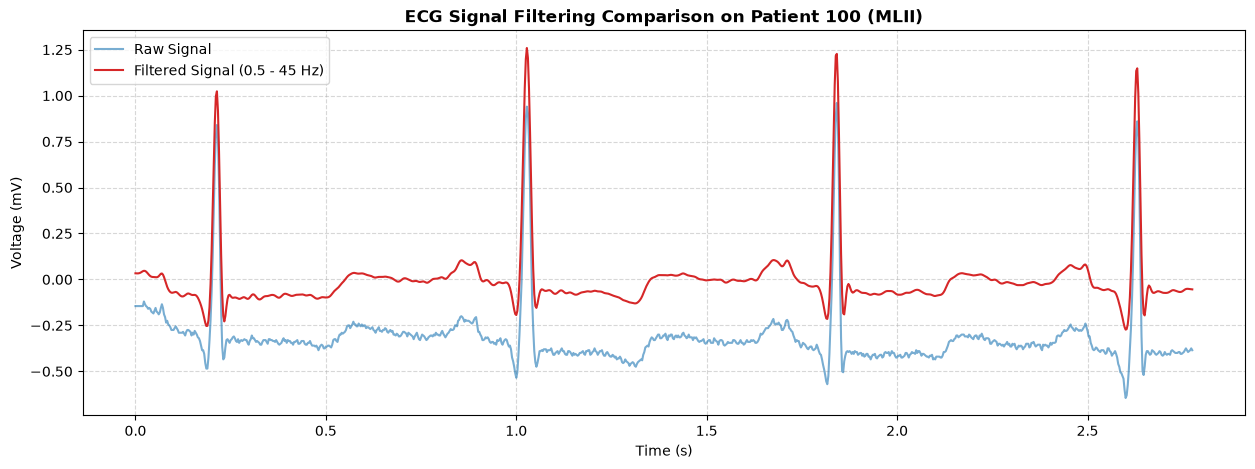

In [37]:
record_name = os.path.join(DATA_DIR, "100")
signals, fields = wfdb.rdsamp(record_name)
raw_signal = signals[:, 0]  # Use lead MLII

filtered_signal = bandpass_filter(raw_signal, fs=fields['fs'])

time = np.arange(1000) / fields['fs']

plt.figure(figsize=(15, 5))
plt.plot(time, raw_signal[:1000], label="Raw Signal", alpha=0.6, color='tab:blue')
plt.plot(time, filtered_signal[:1000], label="Filtered Signal (0.5 - 45 Hz)", color='tab:red', linewidth=1.5)
plt.title("ECG Signal Filtering Comparison on Patient 100 (MLII)", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
save_plot("filter_comparison", caption="ECG signal filtering comparison on Record 100 before and after applying the 0.5-45 Hz Butterworth bandpass filter.")
plt.show()

## 3. Heartbeat Segmentation & Z-Score Normalization

To feed the data into neural networks, we must segment the continuous ECG into individual heartbeats. 

We centered each heartbeat at its R-peak sample index, extracting a window of **180 samples** (90 samples before and 90 samples after the peak). This duration (0.5 seconds at 360 Hz) is medically sufficient to capture the QRS complex, P-wave, and T-wave of a beat.

We also apply **Z-score normalization** to each individual segment to remove baseline offset and scale variations across patient recordings.

In [38]:
from mit_bih import AAMI_MAPPING, segment_record


## 4. Segmenting and Storing the Full Dataset

We loop through all 48 records of the database. We will also track the **Patient Record ID** for each heartbeat segment. This is crucial for splitting data in our federated learning simulation (each patient record = one distinct local client).

In [39]:
from mit_bih import process_and_segment_records

record_ids = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

X_data, y_data, patient_data = process_and_segment_records(record_ids, DATA_DIR)


Starting dataset processing and segmentation...


## 5. Visualize Mapped Heartbeats

Let's plot the average heartbeat for each of the five AAMI classes to see how their morphology differs.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/average_morphologies_20260628_120459.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/average_morphologies_20260628_120459.txt


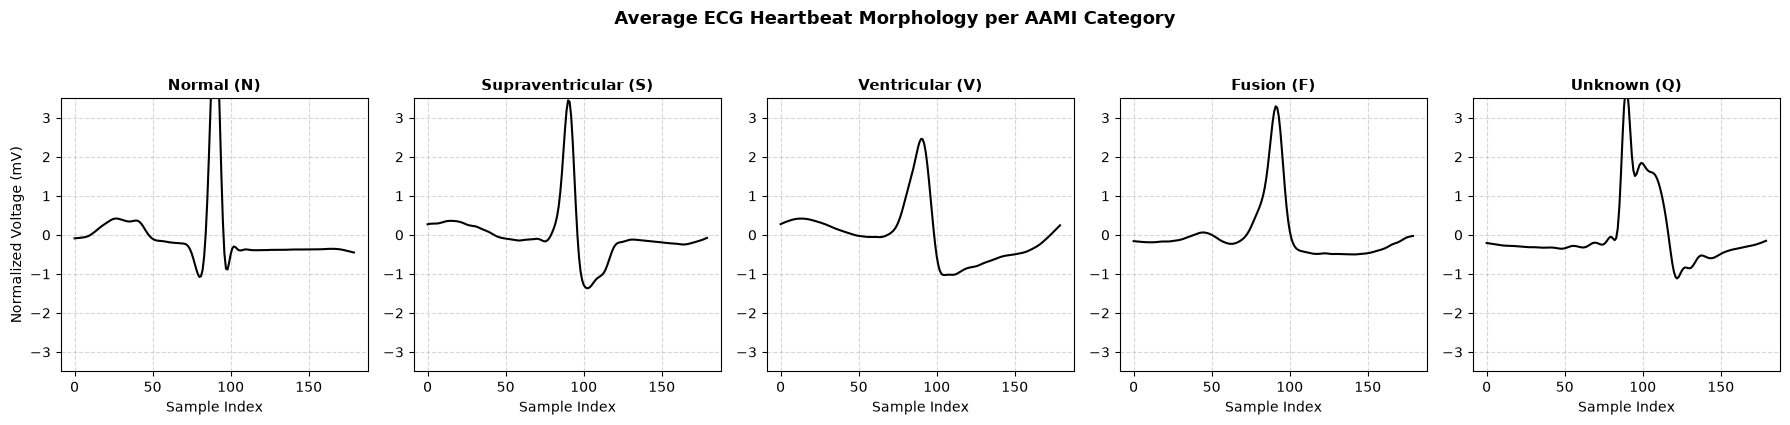

In [40]:
classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
plt.figure(figsize=(18, 4))

for i in range(5):
    idxs = np.where(y_data == i)[0]
    if len(idxs) > 0:
        # Calculate mean morphology over the first 100 beats of this class
        mean_morphology = np.mean(X_data[idxs[:100]], axis=0)
        plt.subplot(1, 5, i + 1)
        plt.plot(mean_morphology, color='black', linewidth=1.5)
        plt.title(classes[i], fontsize=11, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(-3.5, 3.5)
        if i == 0:
            plt.ylabel("Normalized Voltage (mV)")
        plt.xlabel("Sample Index")

plt.suptitle("Average ECG Heartbeat Morphology per AAMI Category", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
save_plot("average_morphologies", caption="Subplots of average heartbeat morphologies across all 5 AAMI categories (Normal, Supraventricular, Ventricular, Fusion, and Unknown).")
plt.show()

## 6. Export Preprocessed Data

We save the final arrays to disk inside `data/processed/` so they can be loaded by our local model and federated learning notebooks.

In [41]:
np.save(os.path.join(OUTPUT_DIR, "X.npy"), X_data)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y_data)
np.save(os.path.join(OUTPUT_DIR, "patient_ids.npy"), patient_data)
print(f"Exported preprocessed files successfully to {OUTPUT_DIR}")

Exported preprocessed files successfully to /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/data


## 7. Conclusions and Next Steps

In this notebook we:
1. Implemented a Butterworth bandpass filter (0.5 to 45 Hz) to remove noise.
2. Segmented continuous signals into 180-sample windows centered around R-peaks.
3. Standardized the amplitude of heartbeats using Z-score normalization.
4. Visualized the average morphologies across AAMI classes, confirming distinct features (e.g., ventricular PVC beats have wide, high-voltage complexes compared to normal beats).
5. Exported clean datasets to `data/processed/`.

In the next notebook (**`03_local_model_training.ipynb`**), we will define a 1D Convolutional Neural Network (CNN) in PyTorch and train it centrally as our model baseline.